# Training a Linear Regresion Model


### Import necessary libraries, packages and modules

In [1]:
# import necessary modules and libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the data and preprocess
This is done to understand the data and handle null values and any inconsistencies

In [2]:
# Load the data and preprocess
ecommerce_df = pd.read_csv('ecommerce_bigdata.csv')
print(ecommerce_df.index)
print(ecommerce_df.columns)

# Check for null values
ecommerce_df.isna().any()


RangeIndex(start=0, stop=200, step=1)
Index(['TransactionID', 'Date', 'Region', 'ProductCategory', 'CustomerType',
       'Sales', 'Profit'],
      dtype='str')


TransactionID      False
Date               False
Region             False
ProductCategory    False
CustomerType       False
Sales              False
Profit             False
dtype: bool

### Create training and testing data
Columns `TransactionID`, `Date`, `Region`, `ProductCategory`, `CustomerType` have been eliminated partly cause some are not necessary but mostly cause they are non-numerical and we shall not be tranforming them to numerical values for now.

**Note**: X must be 2 dimensional (x,1) shaped to be used as a valid indepent variable in regression


In [3]:
# Note that X must be 2 dimensional (x,1) shaped to be used as a valid indepent variable in regression
X = ecommerce_df[['Sales']].values
y = ecommerce_df['Profit'].values


print(X.shape) 
print(y.shape)

(200, 1)
(200,)


### Split the data into training and testing sets

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
for data in [X_train,X_test,y_train,y_test]:
    print(f" {len(data)} rows")

 160 rows
 40 rows
 160 rows
 40 rows


### Create the model and fit the model onto the training set

In [5]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.18]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.139
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[19037.01]


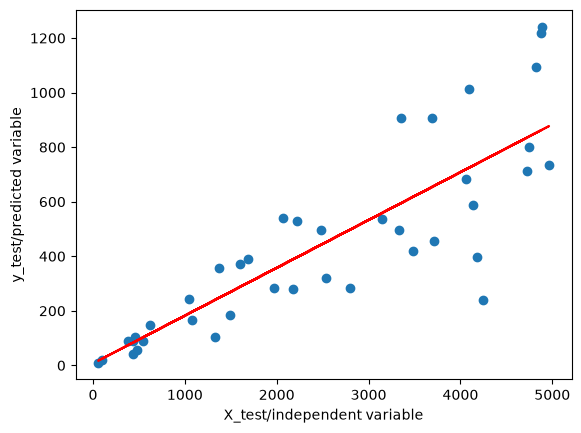

0.714205182890905


In [7]:
predicted = reg.predict(X_test)
r_squared = reg.score(X_test,y_test)

plt.scatter(X_test,y_test)
plt.plot(X_test,predicted,color='red')
plt.xlabel('X_test/independent variable')
plt.ylabel('y_test/predicted variable')
plt.show()
print(r_squared)